# `read_hadrons.C` as a notebook: the ROOT hadron reader by example

The steps of [`read_hadrons.C`](read_hadrons.C), one per cell, with the histograms drawn. It loops
over the events and oversamples of a campaign converted to ROOT
(`prod_AuAu_0_10_jet/run_h5toROOT.py`) with [`HadronFileReader.h`](HadronFileReader.h), which
hands out the hadrons of each oversample as vectors:

| source | reader call | hadron file | what |
|---|---|---|---|
| **bkg** | `r.bkg(e, k)` | `bulk_bg` | background (MUSIC_1) |
| **bkgdep** | `r.bkg_dep(e, k)` | `bulk_jet` | background + deposition (MUSIC_2) |
| **full** | `r.bkg_dep_frag(e, k)` | `bulk_jet` + `jet_frag` | the whole jet event |
| **frag** | `r.frag(e, j)` | `jet_frag` | fragments of the surviving partons |

For charged hadrons at $|\eta| <$ `eta_cut` it fills the $p_T$ spectrum of each source and the
azimuth relative to the event's leading initiator, $\Delta\varphi = \varphi - \varphi_\text{lead}$ in
$[-\pi/2, 3\pi/2)$, and the **wake** = bkgdep − bkg. The histograms and printed yields are the
macro's, bin for bin.

**Kernel: ROOT C++** (`root` in the `js_fno` env; ROOT ≥ 6.34 for the default RNTuple files).
Start it with `root --notebook`, or pick *ROOT C++* in Jupyter. The cells run interpreted (JIT);
on the 67-file campaign below (1005 events, every oversample) the event loop takes 38 s,
the ACLiC-compiled macro 34 s.
Run the cells in order; to change a setting, restart the kernel. (Top-level declarations are
not `const`: cling leaves a `const` global of class type with a run-time initializer empty.)

**Normalization.** Every event is the mean over the oversamples it uses, so a hadron of a sample
weighs $w_e / n_\text{used}$. Each source is averaged over its own samples: bkgdep and full over
the jet leg's, bkg over the background's (a reused background counts once for every event using
it), frag over the fragmentations. $w_e = 1/N$ per event, or $\sigma_k / N_k$ of its pTHat window
with `xsec` (in mb). Flagged events are left out.

## 1. Settings

The macro's arguments. `HADRON_DIR`, `HADRON_OUT` and `MAX_SAMPLES` in the environment override `dir`, `out` and `max_samples`.

In [1]:
// HADRON_DIR: the directory with the <stem>_hadrons.root files and its *_campaign.root, if any
// (HadronFileReader takes the cross sections from there, else from the files)
std::string dir = gSystem->Getenv("HADRON_DIR") ? gSystem->Getenv("HADRON_DIR")
                                                : "../prod_AuAu_0_10_jet/out";
int window = -1;                     // pTHat window, -1: all
bool xsec = false;                   // true: weigh each event with sigma_k / N_k of its window [mb]
double eta_cut = 1.0;                // charged hadrons at |eta| < eta_cut
std::string out = gSystem->Getenv("HADRON_OUT") ? gSystem->Getenv("HADRON_OUT")
                                                : "read_hadrons.root";   // "" for none
int max_samples = gSystem->Getenv("MAX_SAMPLES") ? atoi(gSystem->Getenv("MAX_SAMPLES")) : -1;
                                     // > 0: only the first max_samples oversamples of each event

## 2. The reader and the histograms

`Hists` holds the two histograms of one source: the $p_T$ spectrum (60 log bins, 0.1–100 GeV) and $\Delta\varphi$ to the leading initiator (72 bins).

In [2]:
#include "HadronFileReader.h"

#include <TCanvas.h>
#include <TColor.h>
#include <TFile.h>
#include <TH1D.h>
#include <TLegend.h>
#include <TMath.h>
#include <TStopwatch.h>

#include <cmath>
#include <map>
#include <string>
#include <vector>

namespace rh {

std::vector<double> log_edges(int n, double lo, double hi) {
  std::vector<double> e(n + 1);
  for (int i = 0; i <= n; ++i) e[i] = lo * std::pow(hi / lo, double(i) / n);
  return e;
}

// the histograms of one source
struct Hists {
  TH1D *pt, *dphi;
  Hists(const std::string &src, const std::string &what) {
    static const auto le = log_edges(60, 0.1, 100.0);
    pt = new TH1D(("h_pt_" + src).c_str(), (what + ";p_{T} [GeV]").c_str(), 60, le.data());
    dphi = new TH1D(("h_dphi_" + src).c_str(),
                    (what + ";#Delta#varphi to the leading initiator").c_str(), 72,
                    -TMath::PiOver2(), 1.5 * TMath::Pi());
    for (TH1D *h : {pt, dphi}) {
      h->SetDirectory(nullptr);
      h->Sumw2();
    }
  }
  // the hadrons of one sample, each with weight w
  void fill(const hadrons_root::Hadrons &hs, double phi_lead, double w) {
    for (const auto &h : hs) {
      pt->Fill(h.pt(), w);
      double d = h.phi() - phi_lead;
      while (d < -TMath::PiOver2()) d += TMath::TwoPi();
      while (d >= 1.5 * TMath::Pi()) d -= TMath::TwoPi();
      dphi->Fill(d, w);
    }
  }
};

}  // namespace rh

Open every `*_hadrons.root` in `dir`, keep charged hadrons at $|\eta| <$ `eta_cut`, and select the hadronized, unflagged events of the window.

In [3]:
hadrons_root::HadronFileReader r(dir);
r.set_charged_eta(eta_cut);                          // charged, |eta| < eta_cut only
auto events = r.select_events(window);      // (no const at a cell's top level: cling)
if (events.empty()) throw std::runtime_error("read_hadrons: no events selected");
if (xsec && r.n_windows() == 0)
  throw std::runtime_error("read_hadrons: xsec needs the cross sections of a --pthat-bins campaign");

std::map<int, long> n_window;                        // selected events per window
for (long e : events) ++n_window[r.info(e).pthat_bin];
printf("%s: %ld event(s), %zu selected", dir.c_str(), r.n_events(), events.size());
if (window >= 0) printf(" in window %d", window);
printf("\n");
for (const auto &[k, n] : n_window) {
  if (k < 0) printf("  no pTHat windows: %ld events\n", n);
  else printf("  window %d: %ld events, sigma = %.4g mb\n", k, n, r.sigma_mb(k));
}

/home/putschke/FNO_Hydro_Data/AuAu_0_10_pth10-40_eta06_c1: 1005 event(s), 1005 selected
  window 0: 335 events, sigma = 0.002294 mb
  window 1: 335 events, sigma = 4.388e-05 mb
  window 2: 335 events, sigma = 2.107e-06 mb


## 3. The event loop

In [4]:
TStopwatch sw;
std::string what = Form("charged hadrons, |#eta| < %g", eta_cut);
rh::Hists bkg("bkg", what), dep("bkgdep", what), full("full", what), frag("frag", what);
for (long e : events) {
  const auto &info = r.info(e);
  const auto *lead = info.leading();
  const double phi_lead = lead ? lead->phi() : 0.0;
  const double we = xsec ? r.sigma_mb(info.pthat_bin) / n_window[info.pthat_bin]
                         : 1.0 / events.size();
  auto used = [](int n, int m) { return m > 0 ? std::min(n, m) : n; };
  const int nj = used(r.n_oversamples(e), max_samples), nb = used(r.n_bg_samples(e), max_samples),
            nf = used(r.n_frag(e), max_samples);
  for (int k = 0; k < nj; ++k) {
    dep.fill(r.bkg_dep(e, k), phi_lead, we / nj);
    full.fill(r.bkg_dep_frag(e, k), phi_lead, we / nj);
  }
  for (int k = 0; k < nb; ++k) bkg.fill(r.bkg(e, k), phi_lead, we / nb);
  for (int j = 0; j < nf; ++j) frag.fill(r.frag(e, j), phi_lead, we / nf);
}
printf("%zu event(s)%s filled in %.1f s\n", events.size(),
       max_samples > 0 ? Form(", at most %d oversamples each", max_samples) : "", sw.RealTime());

1005 event(s) filled in 38.6 s


## 4. Normalization and the wake

Divide by the bin width, then wake = bkgdep − bkg. The yields are the integrals over $p_T$, per event or in mb.

In [5]:
const char *ylab = xsec ? "d#sigma/dX [mb]" : "dN/dX per event";
for (rh::Hists *h : {&bkg, &dep, &full, &frag})
  for (TH1D *x : {h->pt, h->dphi}) {
    x->Scale(1.0, "width");
    x->GetYaxis()->SetTitle(ylab);
  }
rh::Hists wake("wake", what + ", bkg + deposition - bkg");
wake.pt->Add(dep.pt, bkg.pt, 1, -1);
wake.dphi->Add(dep.dphi, bkg.dphi, 1, -1);
for (TH1D *x : {wake.pt, wake.dphi}) x->GetYaxis()->SetTitle(ylab);

printf("read_hadrons: %zu event(s)%s, %s:\n", events.size(),
       window >= 0 ? Form(" in window %d", window) : "", what.c_str());
for (rh::Hists *h : {&bkg, &dep, &frag, &full, &wake})
  printf("  %-7s N = %10.4g   (%s)\n", h->pt->GetName() + 5, h->pt->Integral("width"),
         xsec ? "mb" : "per event");

read_hadrons: 1005 event(s), charged hadrons, |#eta| < 1:
  bkg     N =       1298   (per event)
  bkgdep  N =       1307   (per event)
  frag    N =       7.27   (per event)
  full    N =       1315   (per event)
  wake    N =      9.393   (per event)


## 5. Figures

The $p_T$ spectra of the four sources. On a log scale bkg and bkgdep are hard to tell apart; their difference, the wake, is the next figure.

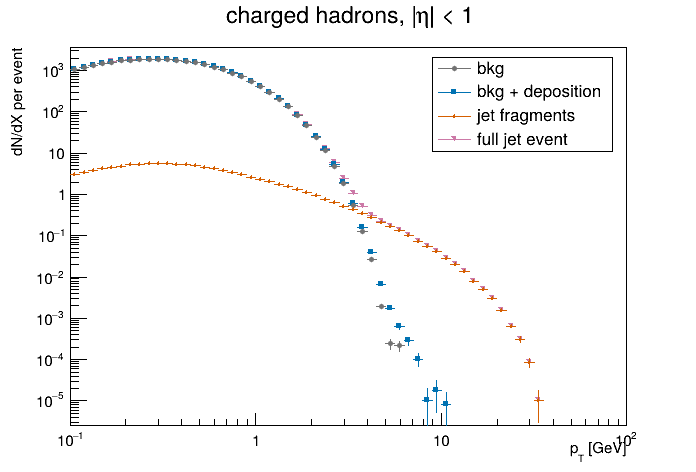

In [6]:
%jsroot off
// %jsroot on: interactive JSROOT figures instead of PNGs
// the colours of the Python analysis notebooks (wake_hadrons.ipynb)
int c_bkg = TColor::GetColor("#737373"), c_dep = TColor::GetColor("#0072B2"),
    c_wake = TColor::GetColor("#009E73"), c_frag = TColor::GetColor("#D55E00"),
    c_full = TColor::GetColor("#CC79A7");
auto style = [](TH1D *h, int c, int m) {
  h->SetLineColor(c);
  h->SetMarkerColor(c);
  h->SetMarkerStyle(m);
  h->SetMarkerSize(0.7);
  h->SetStats(false);
};
style(bkg.pt, c_bkg, 20);   style(dep.pt, c_dep, 21);   style(full.pt, c_full, 23);
style(frag.pt, c_frag, 33); style(wake.pt, c_wake, 22);
style(bkg.dphi, c_bkg, 20); style(dep.dphi, c_dep, 21); style(full.dphi, c_full, 23);
style(frag.dphi, c_frag, 33); style(wake.dphi, c_wake, 22);

auto c1 = new TCanvas("c1", "pT spectra", 700, 500);
c1->SetLogx();
c1->SetLogy();
full.pt->SetTitle(what.c_str());
full.pt->Draw("E");
for (TH1D *h : {dep.pt, bkg.pt, frag.pt}) h->Draw("E same");
auto l1 = new TLegend(0.62, 0.68, 0.88, 0.88);
l1->AddEntry(bkg.pt, "bkg", "lp");
l1->AddEntry(dep.pt, "bkg + deposition", "lp");
l1->AddEntry(frag.pt, "jet fragments", "lp");
l1->AddEntry(full.pt, "full jet event", "lp");
l1->Draw();
c1->Draw();

The wake (bkgdep − bkg) and the jet fragments, linear in the yield.

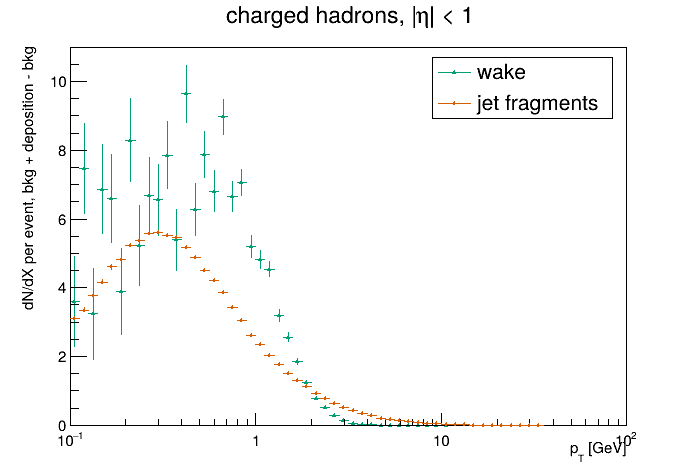

In [7]:
auto c2 = new TCanvas("c2", "wake pT", 700, 500);
c2->SetLogx();
wake.pt->SetTitle(what.c_str());
wake.pt->GetYaxis()->SetTitle(Form("%s, bkg + deposition - bkg", ylab));
wake.pt->Draw("E");
frag.pt->Draw("E same");
auto l2 = new TLegend(0.62, 0.75, 0.88, 0.88);
l2->AddEntry(wake.pt, "wake", "lp");
l2->AddEntry(frag.pt, "jet fragments", "lp");
l2->Draw();
c2->Draw();

The wake and the jet fragments against $\Delta\varphi$ to the event's leading initiator.

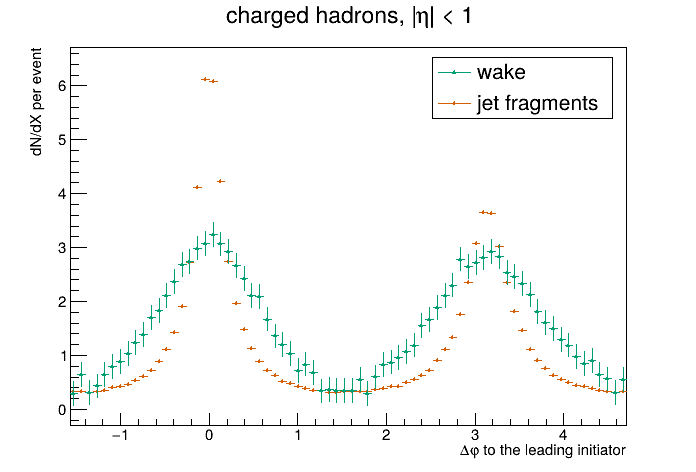

In [8]:
auto c3 = new TCanvas("c3", "dphi", 700, 500);
double lo = std::min(wake.dphi->GetMinimum(), frag.dphi->GetMinimum()),
       hi = std::max(wake.dphi->GetMaximum(), frag.dphi->GetMaximum());
frag.dphi->SetTitle(what.c_str());
frag.dphi->GetYaxis()->SetRangeUser(lo - 0.1 * (hi - lo), hi + 0.1 * (hi - lo));
frag.dphi->Draw("E");
wake.dphi->Draw("E same");
auto l3 = new TLegend(0.62, 0.75, 0.88, 0.88);
l3->AddEntry(wake.dphi, "wake", "lp");
l3->AddEntry(frag.dphi, "jet fragments", "lp");
l3->Draw();
c3->Draw();

## 6. Write the histograms

The same file as the macro: `h_pt_<source>` and `h_dphi_<source>` for bkg, bkgdep, full, frag and wake.

In [9]:
if (!out.empty()) {
  std::unique_ptr<TFile> fo(TFile::Open(out.c_str(), "RECREATE"));
  for (rh::Hists *h : {&bkg, &dep, &full, &frag, &wake})
    for (TH1D *x : {h->pt, h->dphi}) x->Write();
  fo->Close();
  printf("histograms -> %s\n", out.c_str());
}

histograms -> read_hadrons.root
